# Superstore Sales and Profit Analysis using Python

An exploratory data analysis (EDA) project on the Superstore dataset to identify sales trends, profitability drivers, and business challenges using Python, Pandas, and Matplotlib.

## Project Overview

The objective of this project is to analyze retail sales data from the Superstore dataset and derive meaningful business insights.

The analysis focuses on:
- Sales performance over time
- Category and sub-category performance
- Profitability analysis
- Regional and state-wise performance
- The relationship between discounts and profit
- Root-cause analysis of Texas's poor profitability

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("./Data/SampleSuperstore.csv",encoding='cp1252')

## Dataset Information

The Superstore dataset contains information about customer orders, products, sales, discounts, profits, and geographical regions.

Dataset Size:
- Rows: 9,994
- Columns: 21

The objective of this project is to analyze sales performance, profitability, and identify business challenges and opportunities.

## Data Inspection

The first step is to inspect the dataset structure, available features, and data types before performing any analysis.

In [6]:
df.shape

(9994, 21)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [9]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Cleaning

The dataset is checked for:
- Missing values
- Duplicate records
- Incorrect data types

Data quality checks ensure reliable analysis and accurate business insights.

In [11]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

## Data Type Conversion

The Order Date and Ship Date columns are converted from object type to datetime format to enable time-based analysis and feature engineering.

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Feature Engineering

Additional features were created to support analysis:

- Order Year
- Month Name
- Shipping Days

These features help analyze sales trends and delivery performance.

In [16]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

In [17]:
df['Month Name'] = df['Order Date'].dt.month_name()

In [18]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

## Key Performance Indicators (KPIs)

The following business metrics are calculated:

- Total Sales
- Total Profit
- Total Orders
- Average Shipping Days

These KPIs provide a high-level overview of business performance.

In [19]:
total_sales = df['Sales'].sum().round(2)
total_sales_display = f"{total_sales:,.2f}"

In [20]:
total_sales

np.float64(2297200.86)

In [21]:
total_profit = df['Profit'].sum().round(2)
total_profit_display = f"{total_profit:,.2f}"

In [22]:
total_profit

np.float64(286397.02)

In [23]:
total_orders = df['Order ID'].nunique()
total_orders_display = f"{total_orders:,.2f}"

In [24]:
avg_shipping_days=df['Shipping Days'].mean().round(2)

In [25]:
avg_shipping_days

np.float64(3.96)

## Monthly Sales Trend Analysis

Objective:
Analyze how sales vary throughout the year and identify seasonal purchasing patterns.

Method:
Aggregate monthly sales and visualize them using a line chart.

In [26]:
month_table = df.groupby(['Order Month','Month Name'])['Sales'].sum().round(2).reset_index()
print(month_table)

    Order Month Month Name      Sales
0             1    January   94924.84
1             2   February   59751.25
2             3      March  205005.49
3             4      April  137762.13
4             5        May  155028.81
5             6       June  152718.68
6             7       July  147238.10
7             8     August  159044.06
8             9  September  307649.95
9            10    October  200322.98
10           11   November  352461.07
11           12   December  325293.50


In [27]:
import matplotlib.pyplot as plt

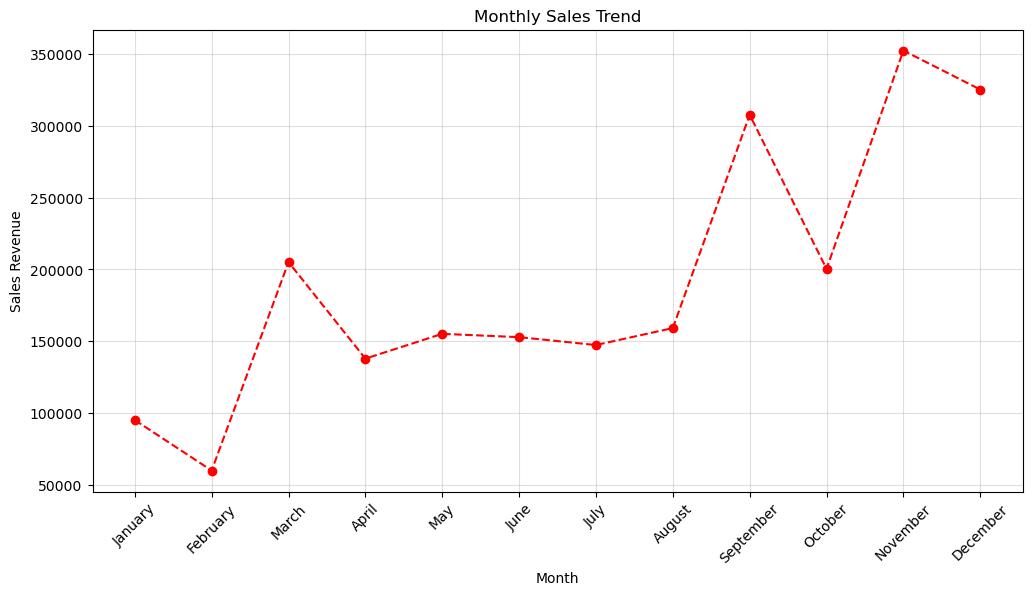

In [28]:
plt.figure(figsize=(12,6))
plt.plot(month_table['Month Name'],month_table['Sales'],'ro--')
plt.xlabel("Month")
plt.ylabel("Sales Revenue")
plt.title("Monthly Sales Trend")
plt.grid(True,alpha=0.4)
plt.xticks(rotation=45)
plt.show()

### Insights

- November recorded the highest sales.
- February recorded the lowest sales.
- Sales increased significantly during the final quarter.

Business Implication:
The company experiences strong year-end demand and should prepare inventory and marketing campaigns accordingly.

## Category-wise Sales Analysis

Objective:
Determine the contribution of each product category to total sales.

Method:
Aggregate sales by category and visualize their contribution using a pie chart.

In [29]:
categories = df.groupby('Category')['Sales'].sum().round(2)
categories

Category
Furniture          741999.80
Office Supplies    719047.03
Technology         836154.03
Name: Sales, dtype: float64

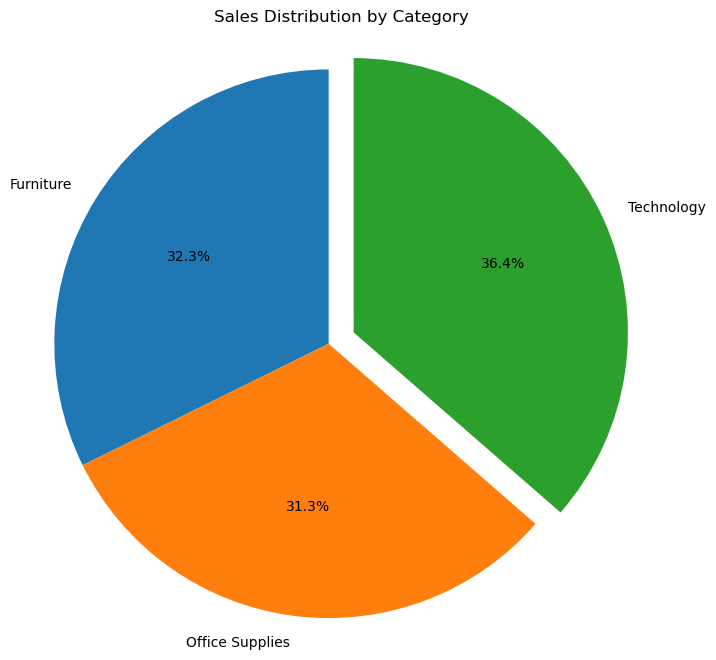

In [30]:
plt.figure(figsize=(8, 8))
plt.pie(
    categories.values,
    labels=categories.index,
    autopct='%1.1f%%',
    explode=[0,0,0.1],
    startangle=90
)
plt.axis('equal')
plt.title("Sales Distribution by Category")
plt.show()

### Insights

- Technology generated the highest share of sales.
- Furniture and Office Supplies contributed nearly equal shares.

Business Implication:
Technology products are major revenue drivers and should remain a strategic focus area.

## Sub-Category Sales Analysis

Objective:
Identify which product sub-categories generate the highest sales and determine major revenue drivers.

In [31]:
sub_categories = df.groupby('Sub-Category')['Sales'].sum().round(2)
sub_categories=sub_categories.sort_values(ascending=False)

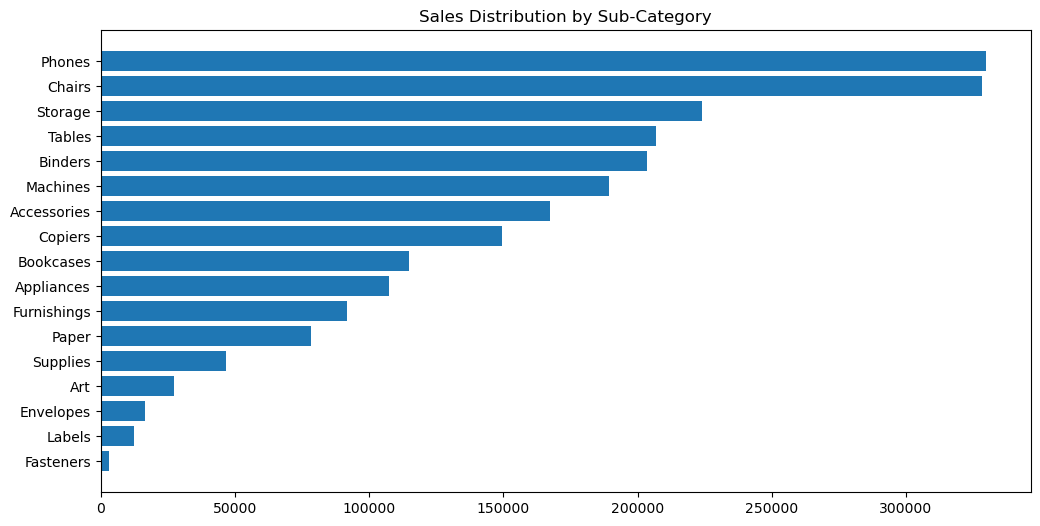

In [32]:
plt.figure(figsize=(12,6))
plt.barh(sub_categories.index,width=sub_categories.values, )
# plt.xlabel("Sub Categories")
# plt.ylabel("Total Sales")
plt.title("Sales Distribution by Sub-Category")
plt.gca().invert_yaxis()
# plt.xticks(rotation=45)
plt.show()

### Insights

Top Performing Sub-Categories:
- Phones
- Chairs
- Storage

Lowest Performing Sub-Categories:
- Fasteners
- Labels
- Envelopes

## Profit by Sub-Category Analysis

Objective:
Determine which sub-categories generate profit and identify loss-making products.

In [33]:
profit_by_subcatories = df.groupby("Sub-Category")['Profit'].sum().round(2)

In [34]:
profit_by_subcatories = profit_by_subcatories.sort_values(ascending=False)

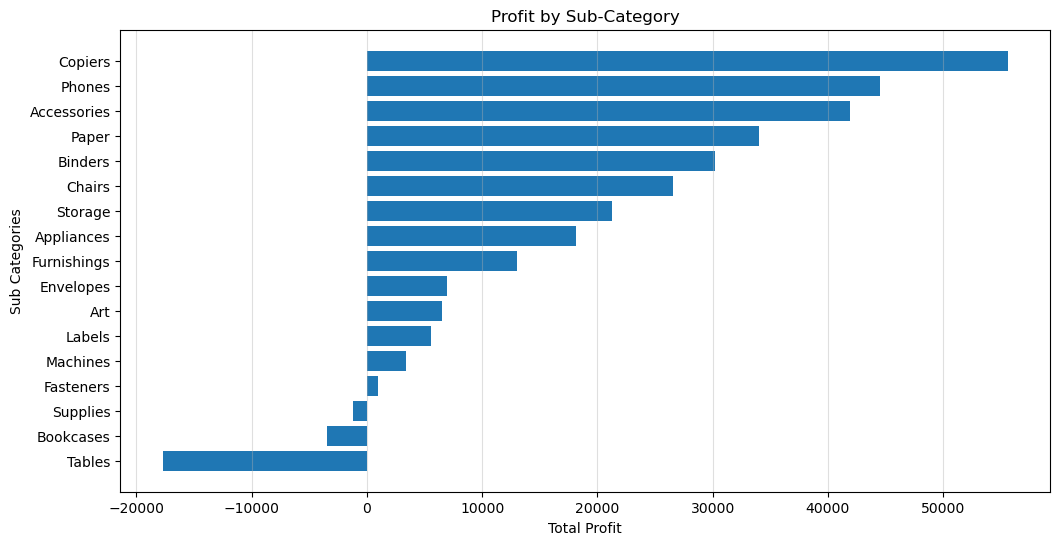

In [35]:
plt.figure(figsize=(12,6))
plt.barh(profit_by_subcatories.index,width=profit_by_subcatories.values)
plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub Categories")
plt.gca().invert_yaxis()
plt.grid(axis='x',alpha=0.4)
plt.show()

### Insights

- Copiers generated the highest profit.
- Supplies, Tables, and Bookcases were loss-making categories.

Business Implication:
Certain products generate revenue but fail to produce positive margins.

## Discount vs Profit Analysis

Objective:
Investigate the relationship between discount levels and profitability.

Method:
Use a scatter plot to examine whether increasing discounts lead to lower profits.

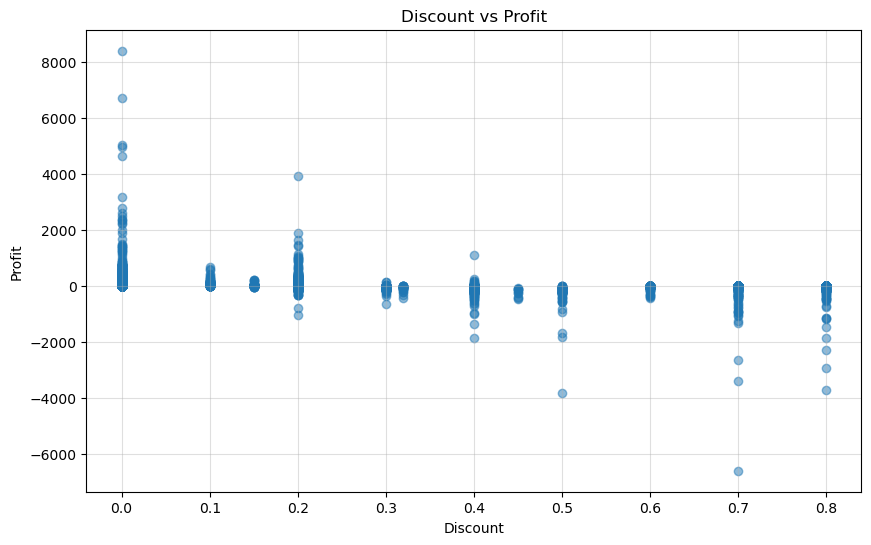

In [36]:
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'],df['Profit'],alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(alpha=0.4)
plt.show()

### Insights

Higher discounts were generally associated with lower profits.

Business Implication:
Aggressive discounting may erode margins and contribute to losses.

## State-wise Sales Analysis

Objective:
Identify the states generating the highest revenue and understand regional sales performance.

In [37]:
sales_by_state = df.groupby('State')['Sales'].sum().round(2)
sales_by_state = sales_by_state.sort_values(ascending=False)

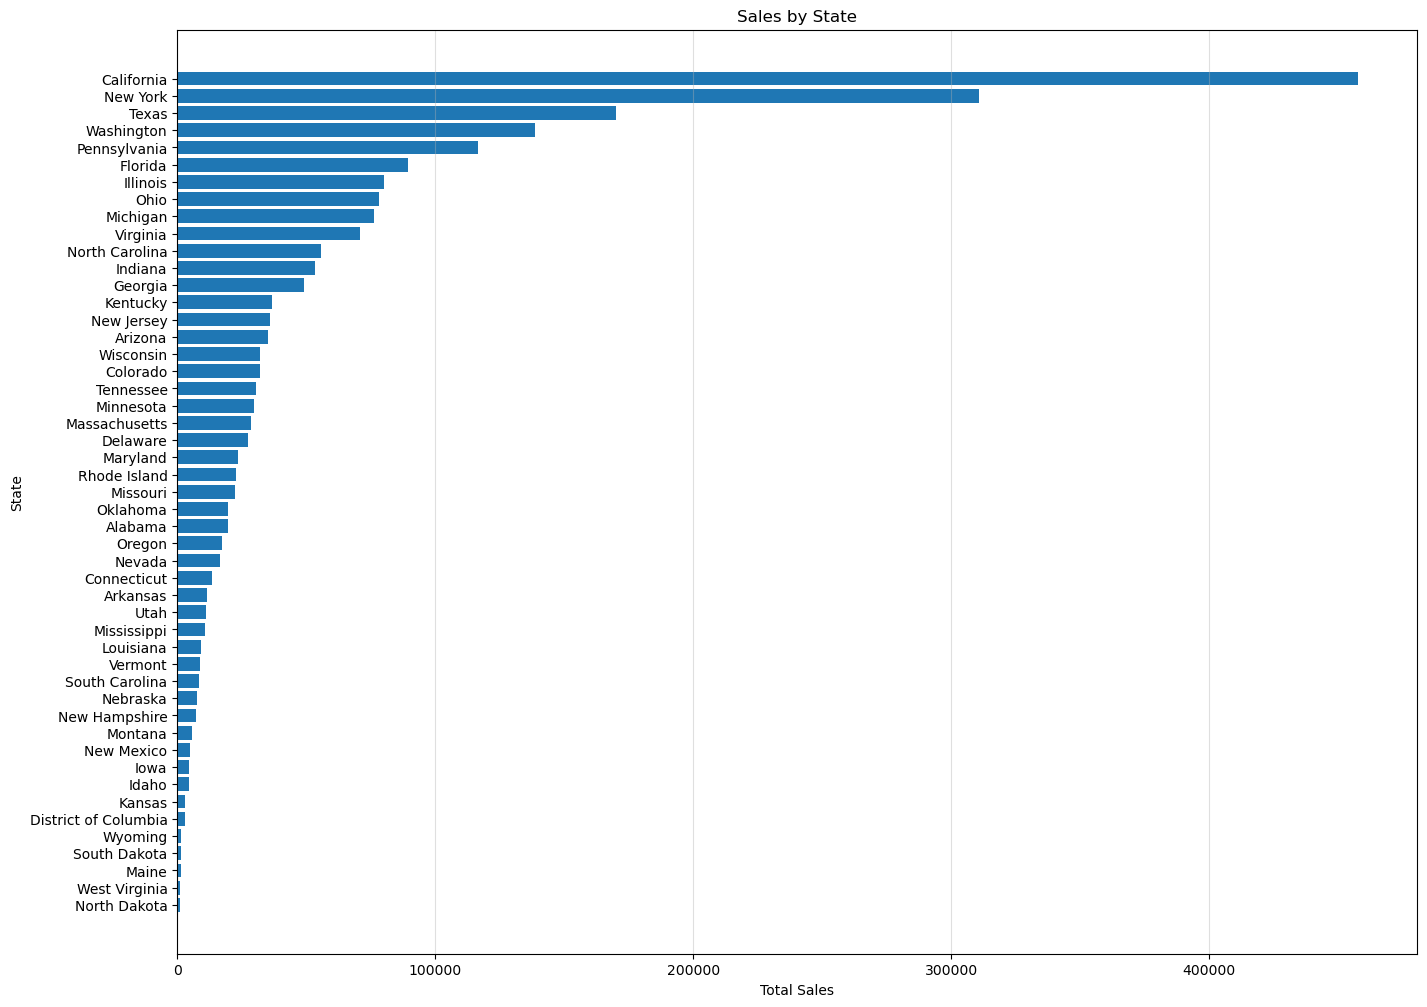

In [38]:
plt.figure(figsize=(16,12))
plt.barh(sales_by_state.index,width=sales_by_state.values)
plt.title("Sales by State")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.grid(axis='x',alpha=0.4)
plt.show()

### Insights

Top Sales States:
- California
- New York
- Texas

## State-wise Profit Analysis

Objective:
Determine the most profitable and least profitable states and compare profitability with sales performance.

In [39]:
profit_by_state = df.groupby('State')['Profit'].sum().round(2)
profit_by_state = profit_by_state.sort_values(ascending=False)

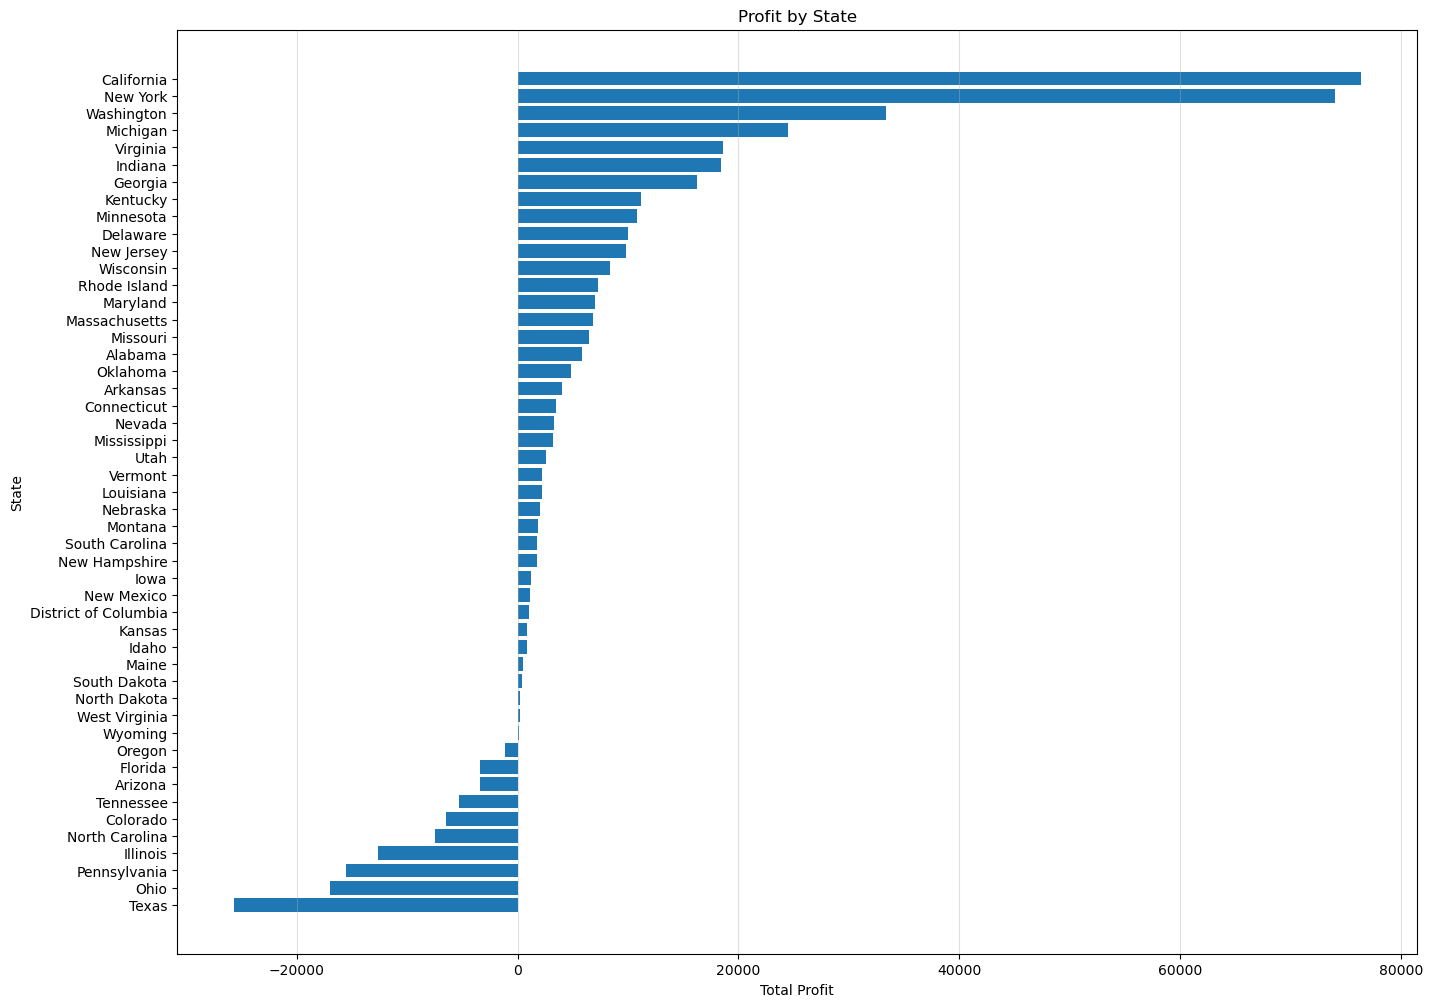

In [40]:
plt.figure(figsize=(16,12))
plt.barh(profit_by_state.index,width=profit_by_state.values)
plt.title("Profit by State")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.grid(axis='x',alpha=0.4)
plt.show()

### Insights

Top Profit States:
- California
- New York
- Washington

Observation:
Texas generated high sales but did not rank among the top profitable states.

# Case Study: Investigating Texas Profitability

Texas was identified as one of the highest-selling states but exhibited poor profitability.

Objective:
Investigate the factors responsible for Texas's weak financial performance and identify potential business issues.

In [41]:
texas_df=df[df['State'] == 'Texas']

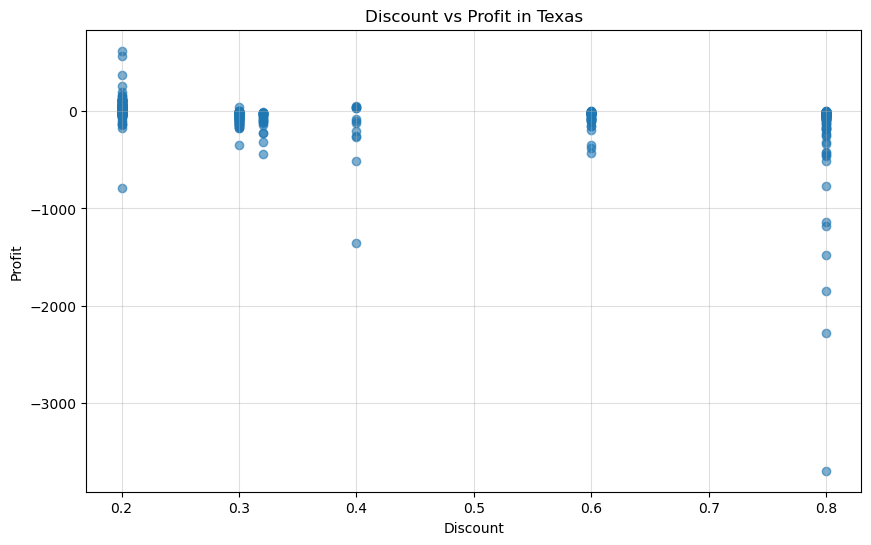

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(texas_df['Discount'], texas_df['Profit'], alpha=0.6)
plt.title("Discount vs Profit in Texas")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(alpha=0.4)
plt.show()


### Findings

- Most loss-making orders occurred at high discount levels.
- Discounts around 80% were strongly associated with negative profits.

Hypothesis:
Aggressive discounting may be the primary reason for Texas's poor profitability.

In [43]:
texas_profit_by_subcategory = texas_df.groupby(['Sub-Category'])['Profit'].sum().round(2)
texas_profit_by_subcategory = texas_profit_by_subcategory.sort_values(ascending=False)

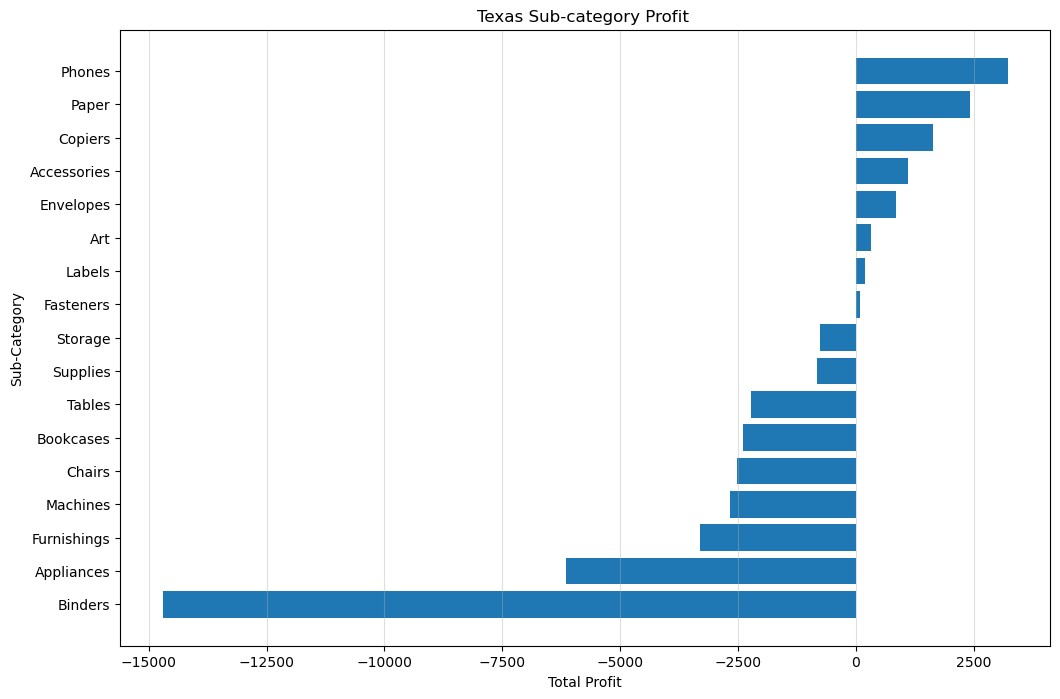

In [44]:
plt.figure(figsize=(12,8))
plt.barh(texas_profit_by_subcategory.index,width=texas_profit_by_subcategory.values)
plt.title("Texas Sub-category Profit ")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
plt.grid(axis='x',alpha=0.4)
plt.show()

### Findings

Top Profitable Sub-Categories:
- Phones
- Paper
- Copiers

Loss-Making Sub-Categories:
- Binders
- Appliances
- Furnishings
- Machines
- Tables
- Bookcases

In [45]:
texas_discount_by_subcategory = texas_df.groupby(['Sub-Category'])['Discount'].mean()
texas_discount_by_subcategory = texas_discount_by_subcategory.sort_values(ascending=False)

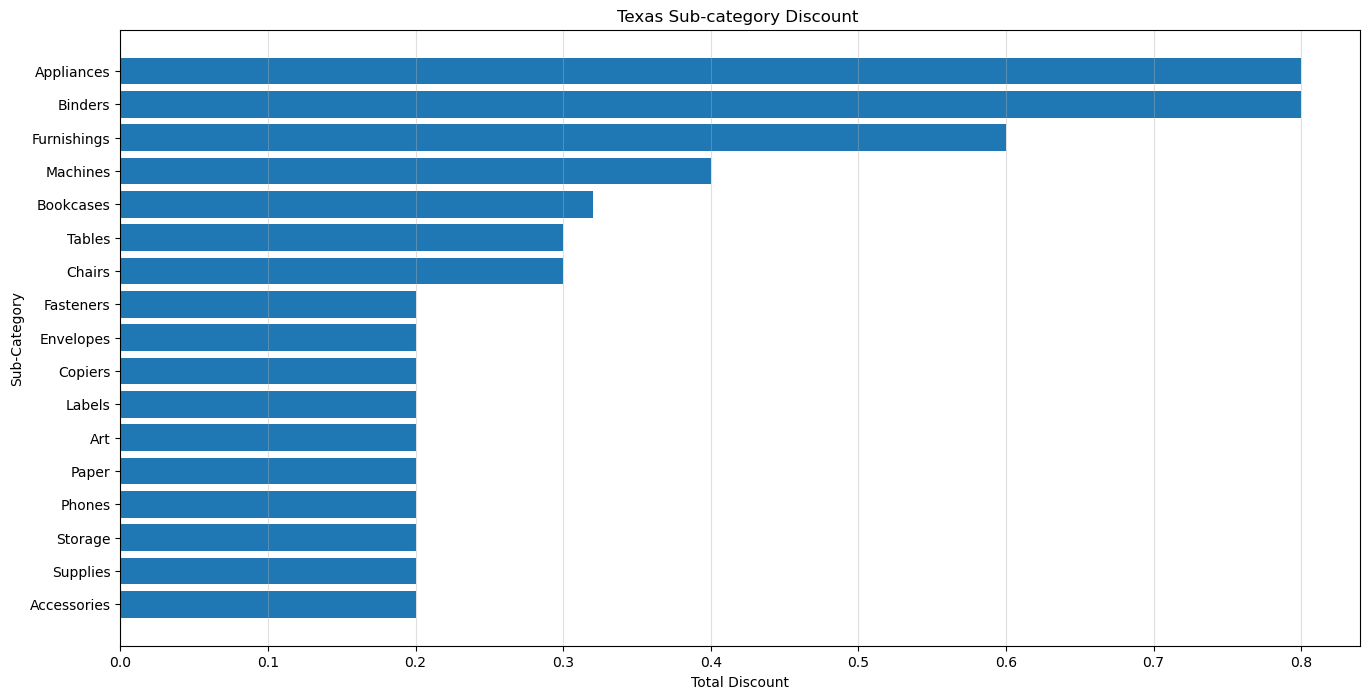

In [47]:
plt.figure(figsize=(16,8))
plt.barh(texas_discount_by_subcategory.index,width=texas_discount_by_subcategory.values)
plt.title("Texas Sub-category Discount ")
plt.xlabel("Total Discount")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
plt.grid(axis='x',alpha=0.4)
plt.show()

### Root Cause Analysis

- Binders and Appliances received average discounts of approximately 80%.
- Furnishings received an average discount of approximately 60%.
- These highly discounted categories were also loss-making.

Conclusion:
Aggressive discounting in specific Texas sub-categories appears to be the primary driver of Texas's poor profitability.

# Conclusion

The analysis revealed that:

- Technology generated the highest share of sales.
- Phones, Chairs, and Storage were top-selling sub-categories.
- Supplies, Tables, and Bookcases were loss-making categories.
- California and New York were highly profitable markets.
- Texas generated high sales but poor profitability.
- High discounts, particularly around 80%, were strongly associated with losses.
- Binders, Appliances, and Furnishings were major contributors to Texas's losses.

# Business Recommendations

- Review discount policies in Texas.
- Restrict extremely high discounts, especially around 80%.
- Reevaluate pricing strategies for Binders, Appliances, and Furnishings.
- Prioritize profitable products such as Phones, Paper, and Copiers.
- Replicate successful strategies from California and New York.